# We analyze the sensitivity of the design to fabrication errors

Due to fabrication imperfections, the design may not turn out exactly as we expect. We want to understand what impacts these fabrication variations will have. Here we consider two types of fabrication imperfections: 

- etch depth (the partial etch goes too far down) $\sim\mathcal{N}(0,5nm)$
- Ovet/underetched (the teeth are too large or small) $\sim\mathcal{N}(0,5nm)$

In [3]:
import autograd.numpy as npa
import numpy as np 
import matplotlib.pyplot as plt
from autograd import value_and_grad

import tidy3d as td
import tidy3d.web as web
td.config.logging_level = "ERROR"

import pickle

from main import (make_sim, get_coupling_efficiency, projection_builder, apodized_to_widths,
                    N_teeth, n_wl, wl_range)

# used for Monte Carlo
seed = 42

We will load our previous optimized designs a little lower down. Lets set up a conveniance function here.

In [4]:
# load files later for us
def load_history(filename):
    with open(filename, "rb") as f:
        file = pickle.load(f)
    return file

This function takes in the parameters of the grating coupler and returns a fucntion that allows you to purturb them.

In [5]:
def make_variation_builder(params):
    widths = params[:-3]
    r0 = params[-3]
    etch_depth = params[-2]
    to_substrate = params[-1]
    
    def variation_builder(etch_delta=0.000,overetch_delta=0.000):
        return make_sim(widths, 
            r0=r0, 
            etch_depth=etch_depth+etch_delta, 
            to_substrate=to_substrate, 
            dilation=overetch_delta)
    
    return variation_builder

In [6]:
# The parameters have a std of 5nm
sigmas = {
    "etch_depth": 0.005,
    "overetch": 0.005
}

## Compute the Variance of Initial optimization with Monti Carlo

We will first compute the variance of the initial optimization using the Monti Carlo method. We sample from the normal distributions defined above to find the distribution.

In [7]:
# pull out the parameters from the initial optimization
data = load_history("data/opt/history.pkl")
param_opt = data['history']['params'][-1]

# make a variation builder fucntion
variation_builder = make_variation_builder(param_opt)

# set up the random seed and number of samples
seed = 42
num_samples = 20

# define standard deviation of the fabrication imperfections
sigma_vector = np.array([
    sigmas["etch_depth"],
    sigmas["overetch"]
])

# sample from the normal distributions
rng = np.random.default_rng(seed)
samples = rng.standard_normal(size=(num_samples, len(sigma_vector))) * sigma_vector

# make a dictionary of the samples
batch_sims = {"nominal": variation_builder()}
batch_sims.update(
    {f"sample_{idx+1}": variation_builder(*tuple(sample)) for idx, sample in enumerate(samples)}
)

In [8]:
# define the batch
batch = web.Batch(simulations=batch_sims,verbose=True)

# run the batch
batch_data = batch.run(path_dir="data/tidy3d_output")

12:47:16 EDT Found all simulations in cache.

Now we plot the distribution across the bandwidth and the average coupling efficency

In [9]:
# pull out the names of the simulations
ordered_names = list(batch_data.keys())
coupling_efficiencies = []
average_coupling_efficiency = []

# grab the coupling efficiencies and average them
for name in ordered_names:
    sim_data = batch_data[name]
    coupling_efficiencies.append(get_coupling_efficiency(sim_data))
    average_coupling_efficiency.append(np.mean(coupling_efficiencies[-1]))

# make everything a nice to work with 
coupling_efficiencies = np.vstack(coupling_efficiencies)
average_coupling_efficiency = np.array(average_coupling_efficiency)
nominal_index = ordered_names.index("nominal")
nominal_coupling_efficiency = coupling_efficiencies[nominal_index]

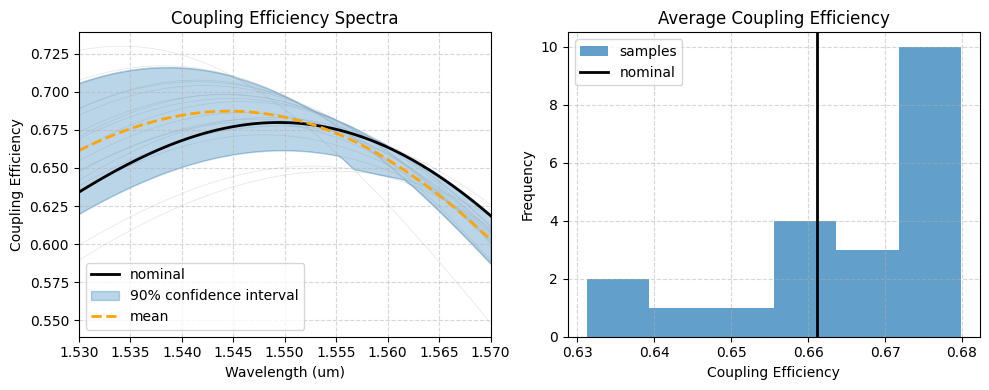

Average Coupling Efficiency Statistics:
  Mean: 0.6656
  Std Dev: 0.0140


In [11]:
fig,ax = plt.subplots(1,2,figsize=(10,4))

# plot the coupling efficiencies 
for name, spectrum in zip(ordered_names, coupling_efficiencies):
    if name == "nominal":
        continue
    ax[0].plot(wl_range, spectrum, color="lightgray", alpha=0.6, linewidth=0.5, zorder=0)

# plot the nominal coupling efficiency
ax[0].plot(wl_range, nominal_coupling_efficiency, color="black", linewidth=2, label="nominal")

# plot the mean and 90% confidence interval
mean_spectrum = np.mean(coupling_efficiencies, axis=0)
precentile90 = np.percentile(coupling_efficiencies, 90, axis=0)
precentile10 = np.percentile(coupling_efficiencies, 10, axis=0)
ax[0].fill_between(wl_range, precentile10, precentile90, color="tab:blue", alpha=0.3, zorder=0, label="90% confidence interval")
ax[0].plot(wl_range, mean_spectrum, color="orange", linewidth=2, linestyle="--", label="mean")


ax[0].set_xlabel("Wavelength (um)")
ax[0].set_ylabel("Coupling Efficiency")
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].set_xlim(wl_range[0], wl_range[-1])
ax[0].legend()
ax[0].set_title("Coupling Efficiency Spectra")

# plot the histogram of the average coupling efficiency
ax[1].hist(average_coupling_efficiency,bins="auto",color="tab:blue",alpha=0.7,label="samples")
ax[1].axvline(average_coupling_efficiency[0],color="black",linewidth=2,label="nominal")
ax[1].set_xlabel("Coupling Efficiency")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Monti Carlo")
ax[1].grid(True, linestyle="--", alpha=0.5)
ax[1].legend()
ax[1].set_title("Average Coupling Efficiency")

plt.tight_layout()
plt.show()

# Print summary statistics of the average coupling efficiency in a nicely formatted way
mean_val = np.mean(average_coupling_efficiency)
std_val = np.std(average_coupling_efficiency)
print("Average Coupling Efficiency Statistics:")
print(f"  Mean: {mean_val:.4f}")
print(f"  Std Dev: {std_val:.4f}")


## Notes on Monti Carlo analysis

In this case we see that the noise actually increases the average coupling on average. This is because we did not fully optimize the design. We will repeat this analysis in the 3D case. 

We also see a fairly tight distribution, this is good, but it will likely be worse for the 3D design.

# Stochastic Gradent Decent Restuls 

We also preformed stochastic gradient decent to decrease the impact of the fabrication variations. We now preform the same Monti Carlo analysis on the results from the stochastic optimization. 

In [12]:
# pull out the parameters from the initial optimization
data_stochastic = load_history("data/opt/history_stochastic.pkl")
param_opt_stochastic = data_stochastic['history']['params'][-1]

# make a variation builder fucntion
variation_builder_stochastic = make_variation_builder(param_opt_stochastic)

# set up the random seed and number of samples
seed = 42
num_samples = 20

# define standard deviation of the fabrication imperfections
sigma_vector = np.array([
    sigmas["etch_depth"],
    sigmas["overetch"]
])

# sample from the normal distributions
rng = np.random.default_rng(seed)
samples = rng.standard_normal(size=(num_samples, len(sigma_vector))) * sigma_vector

# make a dictionary of the samples
batch_sims_stochastic = {"nominal": variation_builder_stochastic()}
batch_sims_stochastic.update(
    {f"sample_{idx+1}": variation_builder_stochastic(*tuple(sample)) for idx, sample in enumerate(samples)}
)

In [13]:
# define the batch
batch_stochastic = web.Batch(simulations=batch_sims_stochastic,verbose=True)

# run the batch
batch_data_stochastic = batch_stochastic.run(path_dir="data/tidy3d_output")

Output()

13:04:34 EDT Started working on Batch containing 21 tasks.

13:05:06 EDT Maximum FlexCredit cost: 0.525 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

13:05:19 EDT Batch complete.

pull out and plot the coupling efficencies

In [14]:
# pull out the names of the simulations
ordered_names_stochastic = list(batch_data_stochastic.keys())
coupling_efficiencies_stochastic = []
average_coupling_efficiency_stochastic = []

# grab the coupling efficiencies and average them
for name in ordered_names_stochastic:
    sim_data = batch_data_stochastic[name]
    coupling_efficiencies_stochastic.append(get_coupling_efficiency(sim_data))
    average_coupling_efficiency_stochastic.append(np.mean(coupling_efficiencies_stochastic[-1]))

# make everything a nice to work with 
coupling_efficiencies_stochastic = np.vstack(coupling_efficiencies_stochastic)
average_coupling_efficiency_stochastic = np.array(average_coupling_efficiency_stochastic)
nominal_index_stochastic = ordered_names_stochastic.index("nominal")
nominal_coupling_efficiency_stochastic = coupling_efficiencies_stochastic[nominal_index_stochastic]

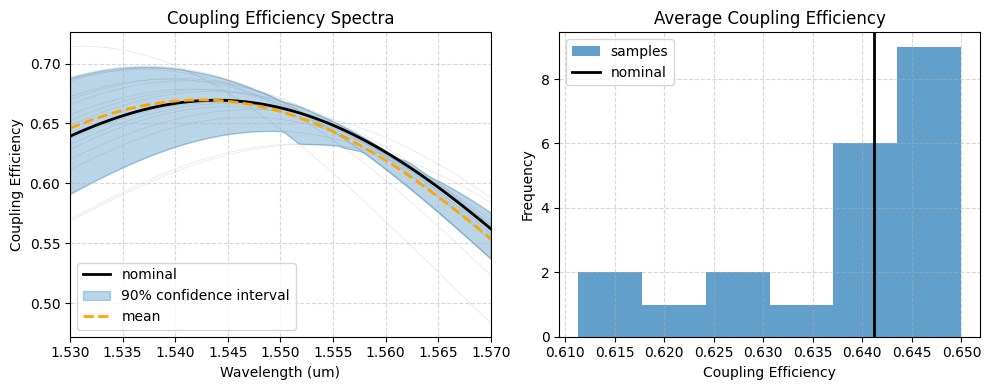

Average Coupling Efficiency Statistics:
  Mean: 0.6388
  Std Dev: 0.0114


In [15]:
fig,ax = plt.subplots(1,2,figsize=(10,4))

# plot the coupling efficiencies 
for name, spectrum in zip(ordered_names_stochastic, coupling_efficiencies_stochastic):
    if name == "nominal":
        continue
    ax[0].plot(wl_range, spectrum, color="lightgray", alpha=0.6, linewidth=0.5, zorder=0)

# plot the nominal coupling efficiency
ax[0].plot(wl_range, nominal_coupling_efficiency_stochastic, color="black", linewidth=2, label="nominal")

# plot the mean and 90% confidence interval
mean_spectrum = np.mean(coupling_efficiencies_stochastic, axis=0)
precentile90 = np.percentile(coupling_efficiencies_stochastic, 90, axis=0)
precentile10 = np.percentile(coupling_efficiencies_stochastic, 10, axis=0)
ax[0].fill_between(wl_range, precentile10, precentile90, color="tab:blue", alpha=0.3, zorder=0, label="90% confidence interval")
ax[0].plot(wl_range, mean_spectrum, color="orange", linewidth=2, linestyle="--", label="mean")


ax[0].set_xlabel("Wavelength (um)")
ax[0].set_ylabel("Coupling Efficiency")
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].set_xlim(wl_range[0], wl_range[-1])
ax[0].legend()
ax[0].set_title("Coupling Efficiency Spectra")

# plot the histogram of the average coupling efficiency
ax[1].hist(average_coupling_efficiency_stochastic,bins="auto",color="tab:blue",alpha=0.7,label="samples")
ax[1].axvline(average_coupling_efficiency_stochastic[0],color="black",linewidth=2,label="nominal")
ax[1].set_xlabel("Coupling Efficiency")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Monti Carlo")
ax[1].grid(True, linestyle="--", alpha=0.5)
ax[1].legend()
ax[1].set_title("Average Coupling Efficiency")

plt.tight_layout()
plt.show()

# Print summary statistics of the average coupling efficiency in a nicely formatted way
mean_val = np.mean(average_coupling_efficiency_stochastic)
std_val = np.std(average_coupling_efficiency_stochastic)
print("Average Coupling Efficiency Statistics:")
print(f"  Mean: {mean_val:.4f}")
print(f"  Std Dev: {std_val:.4f}")


# Notes on Monti Carlo for Stochastic

We see a slight drop in the standard deviation, from 1.4% to 1.1%. This is neglagable, but we see that the design we simulated lines up much better with the average design we expect. It is unclear if stochastic optimization is helpful in this case. Let us preform the full 3D optimization to give a final judgment. 